## VISCOELASTICITY COMPLETE PIPELINE

In [2]:
%matplotlib widget

import os
import cv2
import numpy as np
import numpy as np
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pylab import subplot
from matplotlib.colors import LogNorm
from matplotlib.widgets import SpanSelector
from tqdm.auto import tqdm
from scipy.optimize import leastsq

# Set environment variables for OpenCV
os.environ['OPENCV_LOG_LEVEL'] = 'FATAL'
os.environ['OPENCV_FFMPEG_LOGLEVEL'] = "-8"

In [70]:
data = np.load(r'/Volumes/MyMedia SSD/peopeg_mixture/64/LilyMeng_2026-03-04-134327-0000_ISF.npz')
ISF = data['ISF']  
qs = data['qs']         
dts = data['dts']       
qs_meters = qs * 1e6
tmax = -1

In [71]:
# --- REPLACEMENT FOR CELL 40: Bounded A & B Optimization ---
import numpy as np
from scipy.optimize import least_squares

params = np.zeros((ISF.shape[-1], 3))
matrixfit = np.zeros(ISF[:tmax].T.shape)

# DDM Model: A*(1 - exp(-t/tau_c)) + B
def model_ddm(p, dts):
    return p[0] * (1.0 - np.exp(-dts / p[2])) + p[1]

# Residual function in log-space to handle orders of magnitude gracefully
def residual(p, dts, y):
    return np.log(np.maximum(model_ddm(p, dts), 1e-10)) - np.log(np.maximum(y, 1e-10))

for iq, ddm in enumerate(ISF[:tmax].T):
    # Smart initial guesses
    B_guess = np.min(ddm[:3]) if len(ddm) > 3 else ddm.min()
    A_guess = np.ptp(ddm)
    tc_guess = 1.0
    
    # Fit using least_squares with strict positivity bounds [A, B, tau_c]
    res = least_squares(
        residual, 
        x0=[max(A_guess, 1e-6), max(B_guess, 1e-6), tc_guess], 
        bounds=([0, 0, 0], [np.inf, np.inf, np.inf]),
        args=(dts[:tmax], ddm)
    )
    
    params[iq] = res.x
    matrixfit[iq] = model_ddm(res.x, dts[:tmax])

print("A, B, and tau_c optimization complete with strict positive bounds.")

A, B, and tau_c optimization complete with strict positive bounds.


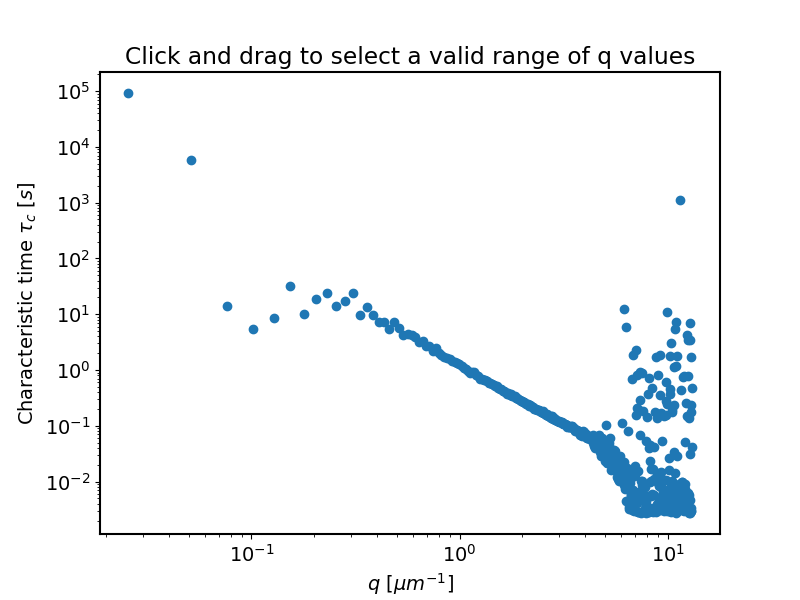

In [72]:
def onselect(xmin, xmax):
    global iqmin, iqmax
    iqmin= np.searchsorted(qs, xmin)
    iqmax = np.searchsorted(qs, xmax)
    print(f"Selected range: {qs[iqmin]:.2f} to {qs[iqmax]:.2f}")

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(qs, params[:, 2], 'o')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$q\ [\mu m^{-1}$]')
ax.set_ylabel(r'Characteristic time $\tau_c\ [s]$')
ax.set_title('Click and drag to select a valid range of q values')

span = SpanSelector(ax, onselect, 'horizontal', useblit=True, interactive=True, props=dict(alpha=0.5, facecolor='red'))
plt.show()

(1000.0, 100000000000.0)

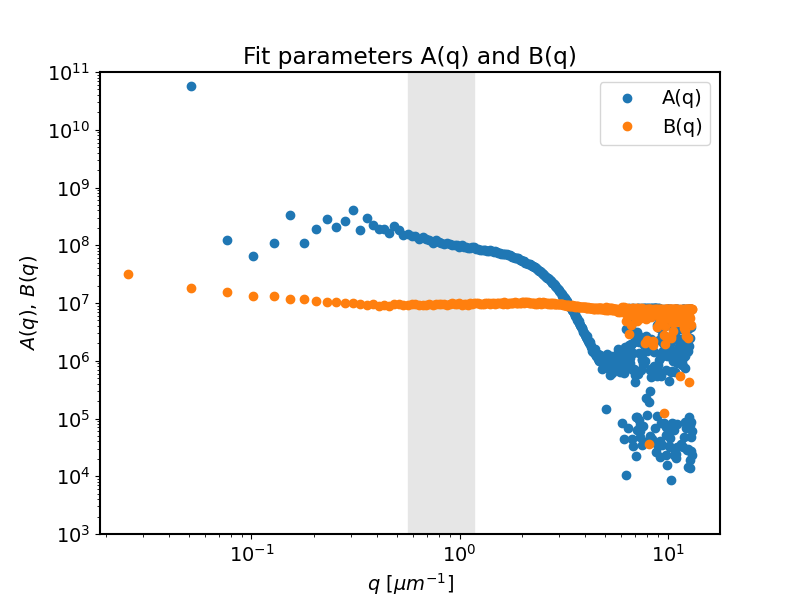

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.title('Fit parameters A(q) and B(q)')
plt.plot(qs, params[:,0], 'o', label="A(q)")
plt.plot(qs, params[:,1], 'o', label="B(q)")
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$q\ [\mu m^{-1}]$')
plt.ylabel(r'$A(q),\, B(q)$')

plt.axvspan(qs[iqmin], qs[iqmax], color=(0.9,0.9,0.9))
plt.legend()
plt.ylim((1e3,1e11))

In [75]:
import numpy as np

# --- MSD from DDM (model-free once A(q), B(q) are known) ---
# f(q, tau) = 1 - (ISF(q, tau) - B(q)) / A(q)

if iqmax <= iqmin:
    raise ValueError("iqmax must be > iqmin. Select a valid q-range first.")

tau_all = dts[:tmax]
q_sel = qs[iqmin:iqmax]
if np.any(q_sel <= 0):
    raise ValueError("Selected q-range includes q<=0. Choose iqmin>0.")
Aq = params[iqmin:iqmax, 0]
Bq = params[iqmin:iqmax, 1]

f_qtau = 1.0 - (ISF[:tmax, iqmin:iqmax] - Bq) / Aq

# Numerical safety: clip to (0, 1]
eps = 1e-10
f_qtau = np.clip(f_qtau, eps, 1.0)

# Choose MSD convention: 6 for 3D MSD, 4 for 2D in-plane MSD.
msd_factor = 4.0
MSD_qtau = -(msd_factor / (q_sel[None, :] ** 2)) * np.log(f_qtau)

# (Averaging over q is done after selecting a valid tau-range.)

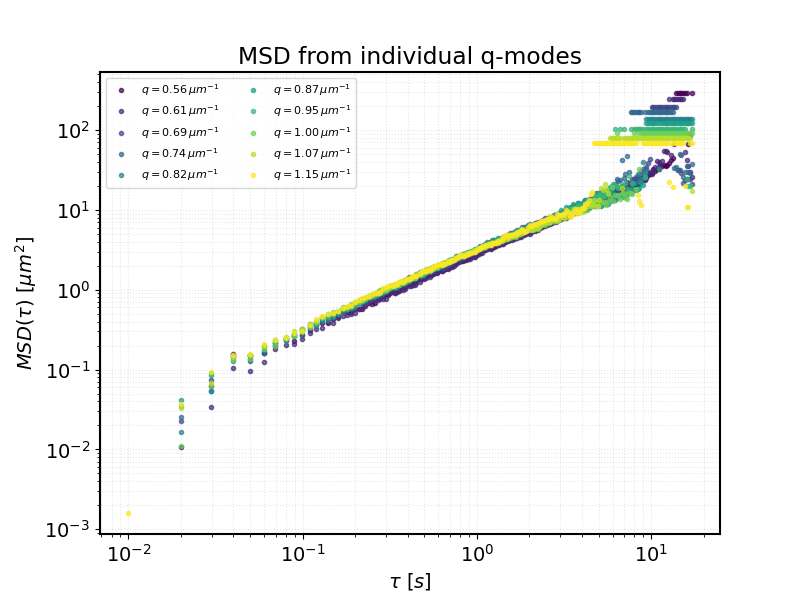

In [76]:
import numpy as np
import matplotlib.pyplot as plt

# Plot MSD(tau) for 10 equally spaced q-values in the selected range
n_show = 10
idx_rel = np.linspace(0, len(q_sel) - 1, n_show, dtype=int)
idx_rel = np.unique(idx_rel)
colors = plt.cm.viridis(np.linspace(0, 1, len(idx_rel)))

plt.figure(figsize=(8, 6))
for c, j in zip(colors, idx_rel):
    plt.plot(tau_all, MSD_qtau[:, j], '.', color=c, alpha=0.7, label=rf"$q={q_sel[j]:.2f}\,\mu m^{{-1}}$")
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\tau\ [s]$')
plt.ylabel(r'$MSD(\tau)\ [\mu m^2]$')
plt.title('MSD from individual q-modes')
plt.legend(ncol=2, fontsize=8)
plt.grid(True, which='both', ls=':', alpha=0.3)

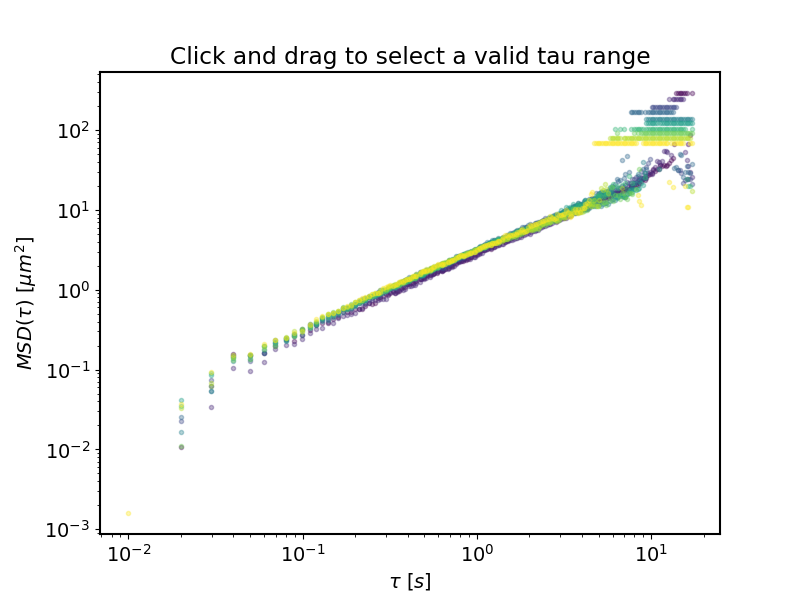

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import SpanSelector

# Default selection: full tau range (override by dragging)
itmin, itmax = 0, len(tau_all)

def onselect_tau(xmin, xmax):
    global itmin, itmax
    xmin, xmax = sorted((xmin, xmax))
    itmin = int(np.searchsorted(tau_all, xmin, side='left'))
    itmax = int(np.searchsorted(tau_all, xmax, side='right'))
    itmin = max(0, min(itmin, len(tau_all) - 1))
    itmax = max(itmin + 1, min(itmax, len(tau_all)))
    print(f"Selected tau range: {tau_all[itmin]:.3g} to {tau_all[itmax-1]:.3g} s (indices {itmin}:{itmax})")

# Plot a subset of q-modes to help choose a tau-window where MSD collapses
n_show = 10
idx_rel = np.linspace(0, len(q_sel) - 1, n_show, dtype=int)
idx_rel = np.unique(idx_rel)
colors = plt.cm.viridis(np.linspace(0, 1, len(idx_rel)))

fig, ax = plt.subplots(figsize=(8, 6))
for c, j in zip(colors, idx_rel):
    ax.plot(tau_all, MSD_qtau[:, j], '.', color=c, alpha=0.35)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$\tau\ [s]$')
ax.set_ylabel(r'$MSD(\tau)\ [\mu m^2]$')
ax.set_title('Click and drag to select a valid tau range')
span_tau = SpanSelector(ax, onselect_tau, 'horizontal', useblit=True, interactive=True, props=dict(alpha=0.3, facecolor='red'))
plt.show()

Using tau range: 0.0997 to 3.65 s (indices 9:135)


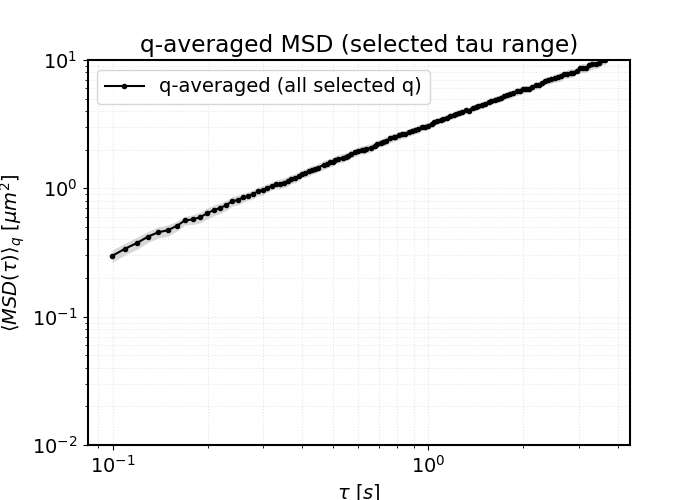

In [79]:
import numpy as np
import matplotlib.pyplot as plt

# Fallback if the interactive selector hasn't been used yet
if 'itmin' not in globals() or 'itmax' not in globals():
    itmin, itmax = 0, len(tau_all)

tau = tau_all[itmin:itmax]
MSD_qtau_sel = MSD_qtau[itmin:itmax, :]

# Average over all selected q
MSD_avg = np.nanmean(MSD_qtau_sel, axis=1)
MSD_std = np.nanstd(MSD_qtau_sel, axis=1)

print(f"Using tau range: {tau[0]:.3g} to {tau[-1]:.3g} s (indices {itmin}:{itmax})")

plt.figure(figsize=(7, 5))
plt.plot(tau, MSD_avg, 'k.-', label='q-averaged (all selected q)')
msd_floor = np.finfo(float).tiny
plt.fill_between(tau, np.maximum(MSD_avg - MSD_std, msd_floor), MSD_avg + MSD_std, color='k', alpha=0.15, linewidth=0)
plt.xscale('log')
plt.ylim(10**-2,10**1)
plt.yscale('log')
plt.xlabel(r'$\tau\ [s]$')
plt.ylabel(r'$\langle MSD(\tau) \rangle_q\ [\mu m^2]$')
plt.title('q-averaged MSD (selected tau range)')
plt.legend()
plt.grid(True, which='both', ls=':', alpha=0.3)

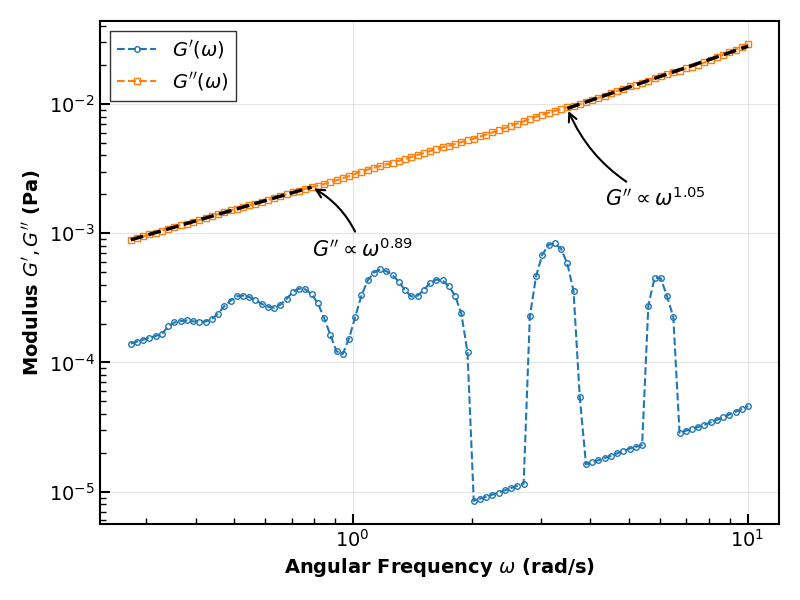

In [85]:
# --- REPLACEMENT FOR CELL 60: Publishable GSER Pipeline with Terminal Fits ---
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d

# --- 1. Physical Constants & Experimental Parameters ---
kb = 1.380649e-23      
T_kelvin = 23.0 + 273.15 
radius_m = 150e-9      # *** CHANGE TO YOUR ACTUAL TRACER RADIUS (meters) ***

# --- 2. Data Prep & Cleaning ---
# (Assuming tau and MSD_avg are already loaded in your environment)
valid = np.isfinite(tau) & (tau > 0) & np.isfinite(MSD_avg) & (MSD_avg > 0)
tau_v = tau[valid]
msd_v = MSD_avg[valid] * 1e-12 # Convert from um^2 (DDM standard) to m^2

# Ensure strictly increasing for interpolation
order_tau = np.argsort(tau_v)
tau_v = tau_v[order_tau]
msd_v = msd_v[order_tau]

log_tau_raw = np.log(tau_v)
log_msd_raw = np.log(msd_v)

# --- 3. Interpolation onto a UNIFORM log grid ---
num_points = 100 
log_tau_uniform = np.linspace(log_tau_raw.min(), log_tau_raw.max(), num_points)

interpolator = interp1d(log_tau_raw, log_msd_raw, kind='linear')
log_msd_uniform = interpolator(log_tau_uniform)

# --- 4. Smoothing and Derivative ---
win = 11
poly = 2
dlogtau = log_tau_uniform[1] - log_tau_uniform[0] 

log_msd_smooth = savgol_filter(log_msd_uniform, window_length=win, polyorder=poly)
alpha = savgol_filter(log_msd_smooth, window_length=win, polyorder=1, deriv=1, delta=dlogtau)

# Soft boundaries to prevent math crashes
alpha = np.clip(alpha, 0.001, 0.999)

# --- 5. Transform back to physical variables ---
omega = 1.0 / np.exp(log_tau_uniform)
msd_smooth = np.exp(log_msd_smooth)

# GSER Calculation
prefactor = (kb * T_kelvin) / (np.pi * radius_m * msd_smooth * gamma(1.0 + alpha))
Gp = prefactor * np.cos(np.pi * alpha / 2.0)
Gpp = prefactor * np.sin(np.pi * alpha / 2.0)

# Sort by frequency for plotting & fitting
order = np.argsort(omega)
omega = omega[order]
Gp = Gp[order]
Gpp = Gpp[order]

# --- 6. Fitting (First 30% and Last 30% of G'') ---
N = len(omega)
idx_30 = int(0.30 * N)
idx_70 = int(0.70 * N)

# --- Low Frequency Fit (First 30%) ---
omega_low = omega[:idx_30]
Gpp_low = Gpp[:idx_30]
coeffs_low = np.polyfit(np.log(omega_low), np.log(Gpp_low), 1)
n_low, A_low = coeffs_low[0], np.exp(coeffs_low[1])

# Extend the plottable line to 45% of the data range for visibility
idx_low_ext = int(0.3 * N)
omega_low_ext = omega[:idx_low_ext]
Gpp_low_line = A_low * (omega_low_ext ** n_low)

# --- High Frequency Fit (Last 30%) ---
omega_high = omega[idx_70:]
Gpp_high = Gpp[idx_70:]
coeffs_high = np.polyfit(np.log(omega_high), np.log(Gpp_high), 1)
n_high, A_high = coeffs_high[0], np.exp(coeffs_high[1])

# Extend the plottable line down to 55% of the data range for visibility
idx_high_ext = int(0.7 * N)
omega_high_ext = omega[idx_high_ext:]
Gpp_high_line = A_high * (omega_high_ext ** n_high)

# --- 7. Publishable Plotting ---
plt.rcParams.update({'font.size': 14, 'axes.linewidth': 1.5})
fig, ax = plt.subplots(figsize=(8, 6))

# Plot raw GSER data
ax.loglog(omega, Gp, marker='o', linestyle='--', mfc='none', markersize=4, markeredgewidth=1, label=r"$G'(\omega)$")
ax.loglog(omega, Gpp, marker='s', linestyle='--', mfc='none', markersize=4, markeredgewidth=1, label=r"$G''(\omega)$")

# Plot extended fit lines
ax.loglog(omega_low_ext, Gpp_low_line, linestyle='--', color='black', linewidth=2.5)
ax.loglog(omega_high_ext, Gpp_high_line, linestyle='--', color='black', linewidth=2.5)

# Add annotations with arrows
# Low freq annotation pointing to the extended end of the black dashed line
ax.annotate(rf"$G'' \propto \omega^{{{n_low:.2f}}}$", 
            xy=(omega_low_ext[-1], Gpp_low_line[-1]), 
            xytext=(0, -50), # Offset text 40 points right, 30 points down
            textcoords='offset points', 
            fontsize=15, color='black',
            arrowprops=dict(arrowstyle="->", color='black', connectionstyle="arc3,rad=.2", lw=1.5))

# High freq annotation pointing to the extended start of the red dashed line
ax.annotate(rf"$G'' \propto \omega^{{{n_high:.2f}}}$", 
            xy=(omega_high_ext[0], Gpp_high_line[0]), 
            xytext=(100, -70), # Offset text 40 points left, 30 points up
            textcoords='offset points', 
            fontsize=15, color='black',
            ha='right', # Horizontally align text to the right so it flows nicely
            arrowprops=dict(arrowstyle="->", color='black', connectionstyle="arc3,rad=-.2", lw=1.5))

# Formatting
ax.set_xlabel(r'Angular Frequency $\omega$ (rad/s)', fontweight='bold')
ax.set_ylabel(r'Modulus $G^\prime, G^{\prime\prime}$ (Pa)', fontweight='bold')

# Ticks and Grid
ax.tick_params(axis='both', which='major', length=7, width=1.5, direction='in')
ax.tick_params(axis='both', which='minor', length=4, width=1, direction='in')
ax.grid(True, which='major', linestyle='-', alpha=0.2, color='gray')

# Legend 
ax.legend(loc='best', frameon=True, edgecolor='black', fancybox=False)

plt.tight_layout()
plt.savefig('GSER_plot_64.png', dpi=300)
plt.show()